# Analyse exploratoire MSPR - Élections et Indicateurs Sociaux
Ce notebook vous permet d'explorer vos données injectées dans PostgreSQL.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

load_dotenv()

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

## Visualisation 1

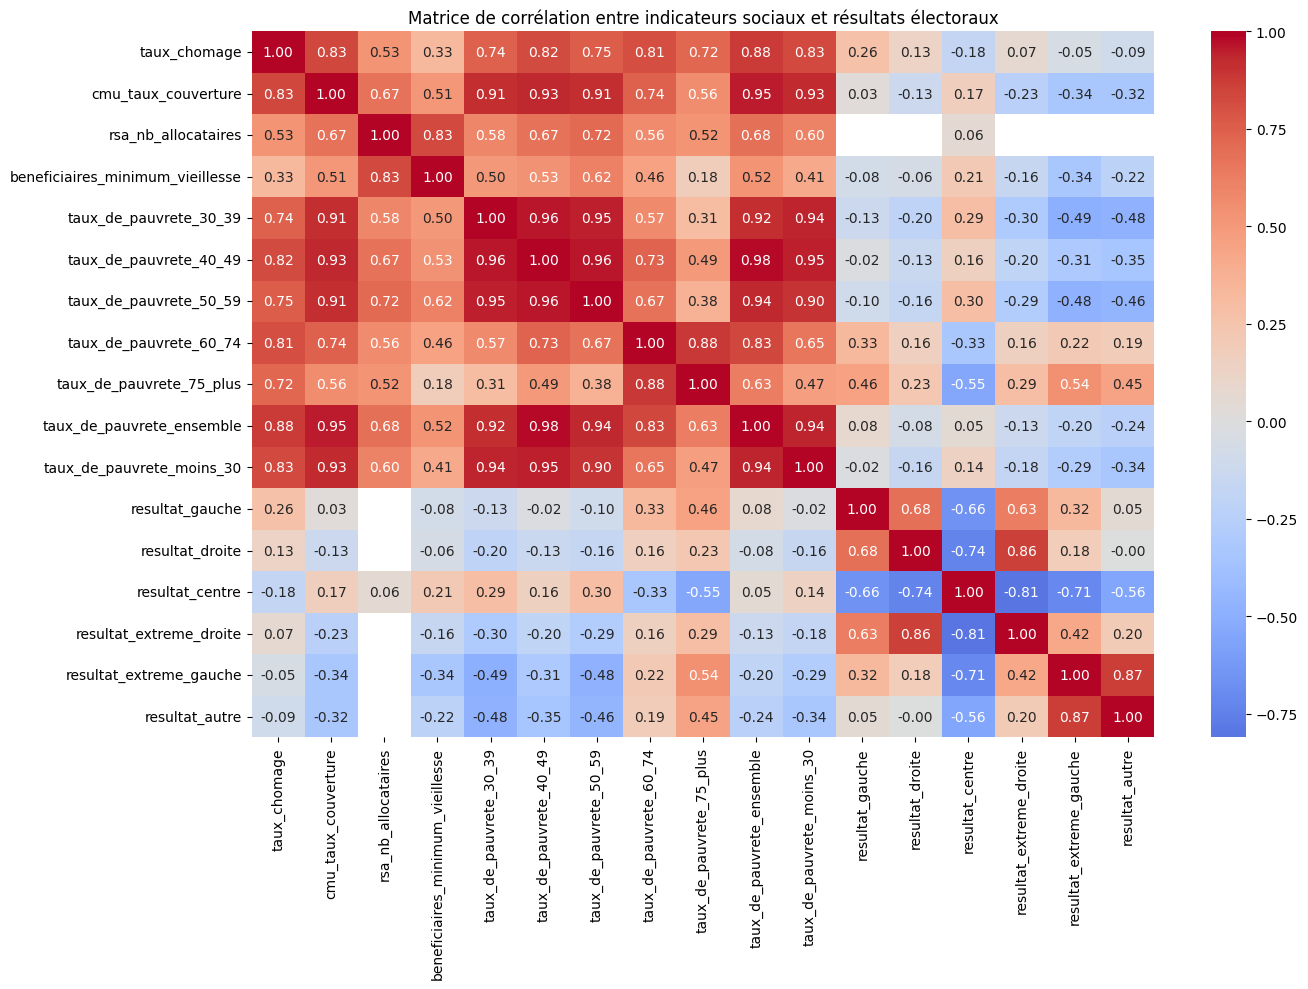

In [20]:
# Charger tous les indicateurs sociaux et électoraux dans un même DataFrame
df_corr = pd.read_sql("""
SELECT 
    s.code_departement, s.annee,
    s.taux_chomage,
    s.cmu_taux_couverture,
    s.rsa_nb_allocataires,
    s.beneficiaires_minimum_vieillesse,
    s.taux_de_pauvrete_30_39,
    s.taux_de_pauvrete_40_49,
    s.taux_de_pauvrete_50_59,
    s.taux_de_pauvrete_60_74,
    s.taux_de_pauvrete_75_plus,
    s.taux_de_pauvrete_ensemble,
    s.taux_de_pauvrete_moins_30,
    r.resultat_gauche,
    r.resultat_droite,
    r.resultat_centre,
    r.resultat_extreme_droite,
    r.resultat_extreme_gauche,
    r.resultat_autre
FROM indicateurs_sociaux s
JOIN resultats_elections r ON s.code_departement = r.code_departement AND s.annee = r.annee
""", engine)

# Supprimer les colonnes non numériques si besoin
df_num = df_corr.drop(columns=["code_departement", "annee"])

# Calculer la matrice de corrélation
corr_matrix = df_num.corr()

# Afficher la heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matrice de corrélation entre indicateurs sociaux et résultats électoraux")
plt.tight_layout()
plt.show()